ACC-100001
250
{"amount": 100, "date": "2025-11-08", "time": "16:57:38.334629", "balance_after": 100, "operation_type": "deposit", "operation_status": "success"}
{"amount": 179, "date": "2025-11-08", "time": "16:57:38.334647", "balance_after": 279, "operation_type": "deposit", "operation_status": "success"}
{"amount": 20, "date": "2025-11-08", "time": "16:57:38.334652", "balance_after": 259, "operation_type": "withdraw", "operation_status": "success"}
{"amount": 9, "date": "2025-11-08", "time": "16:57:38.334654", "balance_after": 250, "operation_type": "withdraw", "operation_status": "success"}
[Operation(amount=179, date=datetime.date(2025, 11, 8), time=datetime.time(16, 57, 38, 334647), balance_after=279, operation_type=<OperationTypeEnum.deposit: 'deposit'>, operation_status=<OperationStatusEnum.success: 'success'>)]


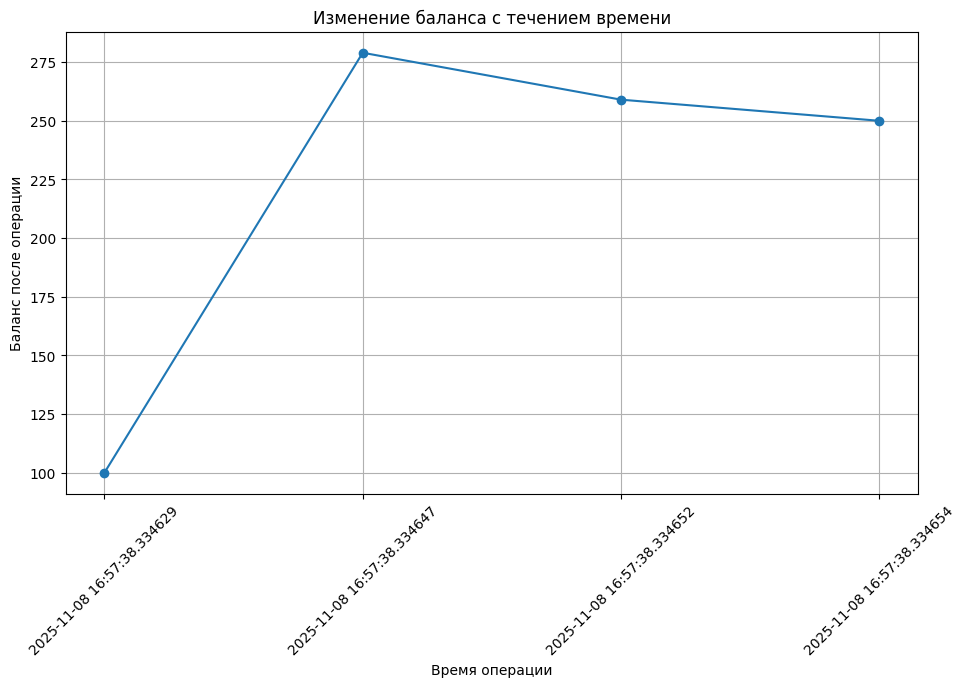

balance 3129.2400000000007


In [7]:
from enum import Enum
from json import dumps
from datetime import datetime
from re import compile, UNICODE
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv, read_json
from dateutil.parser import parse, ParserError

class InvalidAmountError(Exception):
    ...


class InvalidHolderNameError(Exception):
    ...

class CantWithdrawMoreThan50PercentFromSavingsAccountError(Exception):
    ...


class BaseAccountError(Exception):
    ...


class OperationTypeEnum(Enum):
    deposit = 'deposit'
    withdraw = 'withdraw'
    interest = 'interest'

class OperationStatusEnum(Enum):
    success = 'success'
    fail = 'fail'

@dataclass
class Operation:
    amount: int | float
    date: datetime.date
    time: datetime.time
    balance_after: int | float
    operation_type: OperationTypeEnum
    operation_status: OperationStatusEnum

    def __str__(self):
        to_dict = asdict(self)
        to_dict['date'] = str(self.date)
        to_dict['time'] = str(self.time)
        to_dict['operation_type'] = self.operation_type.value
        to_dict['operation_status'] = self.operation_status.value
        return dumps(to_dict)


class Account:
    _account_counter = 100000

    def __init__(self, account_holder: str, balance: float = 0):
        if balance < 0:
            pass

        self.holder = self.__validate_holder_name(account_holder)
        self.operations_history: list[Operation] = []

        Account._account_counter += 1
        self.account_number = f'ACC-{self._account_counter}'

        self._balance = balance
        self._account_counter = Account._account_counter

    def _update_history(
        self,
        operation_type: OperationTypeEnum,
        amount: int | float,
        operation_status: OperationStatusEnum,
        date=None,
        balance_after=None
    ):
        now = datetime.now()
        self.operations_history.append(
            Operation(
                amount,
                now.date() if not date else date.date(),
                now.time() if not date else date.time(),
                self._balance if not balance_after else balance_after,
                operation_type,
                operation_status
            )
        )

    def deposit(self, amount: int | float) -> bool:
        if amount <= 0:
            raise InvalidAmountError('Сумма пополнения должна быть больше нуля')

        self._balance += amount
        self._update_history(OperationTypeEnum.deposit, amount, OperationStatusEnum.success)
        return True

    def withdraw(self, amount: int | float) -> bool:
        if amount <= 0:
            raise InvalidAmountError('Сумма вывода должна быть больше нуля')

        if self._balance < amount:
            self._update_history(OperationTypeEnum.withdraw, amount, OperationStatusEnum.fail)
            return False

        self._balance -= amount
        self._update_history(OperationTypeEnum.withdraw, amount, OperationStatusEnum.success)
        return True

    @property
    def balance(self):
        return self._balance

    @balance.setter
    def balance(self, value):
        self._balance += value

    def get_history(self):
        return self.operations_history

    def plot(self):
        if self.operations_history:
            df = DataFrame(self.operations_history)
            df['datetime'] = df.apply(lambda row: datetime.combine(row['date'], row['time']), axis=1)
            plt.figure(figsize=(11, 6))
            plt.plot(df['datetime'].astype(str), df['balance_after'], marker='o')
            plt.xlabel('Время операции')
            plt.ylabel('Баланс после операции')
            plt.title('Изменение баланса с течением времени')
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.show()
        else:
            raise BaseAccountError("История транзакций отсутствует, невозможно отобразить график")

    def most_valuable_operations(self, n: int):
        return sorted(self.operations_history, key=lambda x: (x.date, x.amount), reverse=True)[:n]

    @staticmethod
    def __validate_holder_name(name: str):
        pattern = compile(
            r'^(?:'
            r'[A-Z][a-z]+'
            r'|'
            r'[А-ЯЁ][а-яё]+'
            r')\s(?:'
            r'[A-Z][a-z]+'
            r'|'
            r'[А-ЯЁ][а-яё]+'
            r')$',
            flags=UNICODE
        )
        if pattern.fullmatch(name):
            return name
        else:
            raise InvalidHolderNameError('Неверный формат имени владельца счёта')

    def load_history(self, file: str):
        if getattr(self, 'account_type'):
            history = None
            if file.endswith('.csv'):
                df = read_csv(file).fillna(0)
                history = df.to_dict(orient='records')

            elif file.endswith('.json'):
                df = read_json(file).fillna(0)
                history = df.to_dict(orient='records')
            
            if history:
                for record in history:
                    if operation_date := self._clean_history(record):
                        self._update_history(
                            OperationTypeEnum(record.get('operation')),
                            record.get('amount'),
                            OperationStatusEnum(record.get('status')),
                            date=operation_date,
                            balance_after=record.get('balance_after')
                        )
    
                        if OperationStatusEnum(record.get('status')) == OperationStatusEnum.success and\
                                OperationTypeEnum(record.get('operation')) == OperationTypeEnum.withdraw:
                            self._balance -= record.get('amount')
                            
                        elif OperationStatusEnum(record.get('status')) == OperationStatusEnum.success:
                            self._balance += record.get('amount')
        else:
            raise BaseAccountError("Не возможно запустить данную операцию в базовом классе")

    def _clean_history(self, record: dict):
        if (account_type := getattr(self, 'account_type')) and (operation_scope := getattr(self, 'operation_scope')):

            if self.account_number == record.get('account_number') and\
                account_type == record.get('account_type') and\
                record.get('operation') in operation_scope:

                    try:
                        date = parse(record.get('date'))

                        if record.get('amount') <= 0 or record.get('amount') == float('nan'):
                            return False

                        if record.get('status') not in {'success', 'fail'}:
                            return False

                        return date
                    except (ParserError, TypeError):
                        return False
        else:
            raise BaseAccountError("Не возможно запустить данную операцию в базовом классе")
            


class CheckingAccount(Account):
    account_type = 'checking'
    operation_scope = {'withdraw', 'deposit'}


class SavingsAccount(Account):
    account_type = 'savings'
    operation_scope = {'withdraw', 'deposit', 'interest'}

    def apply_interest(self, rate: int | float):
        if rate <= 0:
            raise InvalidAmountError('Процент должен быть больше нуля')

        amount = rate * self._balance
        self._balance += amount
        self._update_history(OperationTypeEnum.interest, amount, OperationStatusEnum.success)
        return True

    def withdraw(self, amount: int | float) -> bool:
        if amount > self._balance / 2:
            raise CantWithdrawMoreThan50PercentFromSavingsAccountError(
                'Вы пытаетесь снять более 50% от баланса'
            )

        return super().withdraw(amount)
    
    
    
def main():
    a1 = Account("Philipp Schulz", )
    # получение номера аккаунта
    print(a1.account_number)
    #
    
    # проверка базовых операций
    a1.deposit(100)
    a1.deposit(179)
    a1.withdraw(20)
    a1.withdraw(9)
    print(a1.balance)
    #

    # вывод истории в json формате
    for i in a1.operations_history:
        print(i)
    # 

    # получение последний операций в порядке убывания amount
    print(a1.most_valuable_operations(1))
    #

    # отрисовка графика
    a1.plot()
    #
 
    # Загрузка данных из csv/json. Поле balance_after было решено не обрабатывать, так как в некоторых случаях это требует
    # чтобы на аккаунте уже был какой-то баланс, не подтверждённый транзакцией, я посчитал что это противоречит логики. Соответственно
    # баланс собирается только из подтверждённых транзакций
    a2 = SavingsAccount("Philipp Schulz")
    a2.load_history('Файлы к ДЗ 5/transactions_dirty.csv')
    print('balance', a2.balance)
    
main()
    